In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator
from qiskit.circuit.random import random_circuit
from qiskit import transpile
from qiskit.converters import circuit_to_dag
from qiskit.visualization import plot_histogram, dag_drawer
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit_aer import AerSimulator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch
from torch_geometric.data import Data

# ------------------------- CONFIGURATION -------------------------
service = QiskitRuntimeService(name="Aniket")
backend = service.backend("ibm_brisbane")
noise_model = NoiseModel.from_backend(backend)

In [2]:
num_qubits, depth = 5, 5

random_circ = random_circuit(num_qubits, depth, max_operands=2, measure=True, seed=42)
transpiled_circ = transpile(random_circ, backend=backend)

In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.instruction import Instruction

# Step 1: Extract active physical qubits
active_physical_qubits = sorted({
    qubit._index
    for instr in transpiled_circ.data
    for qubit in instr.qubits
})

# Step 2: Build mapping: hardware qubit index → virtual index (0 to n-1)
hardware_to_virtual = {
    physical: virtual
    for virtual, physical in enumerate(active_physical_qubits)
}

print("\nHardware → Virtual Qubit Mapping:")
for hw, v in hardware_to_virtual.items():
    print(f"Q{hw} → q{v}")


Hardware → Virtual Qubit Mapping:
Q18 → q0
Q19 → q1
Q20 → q2
Q21 → q3
Q53 → q4


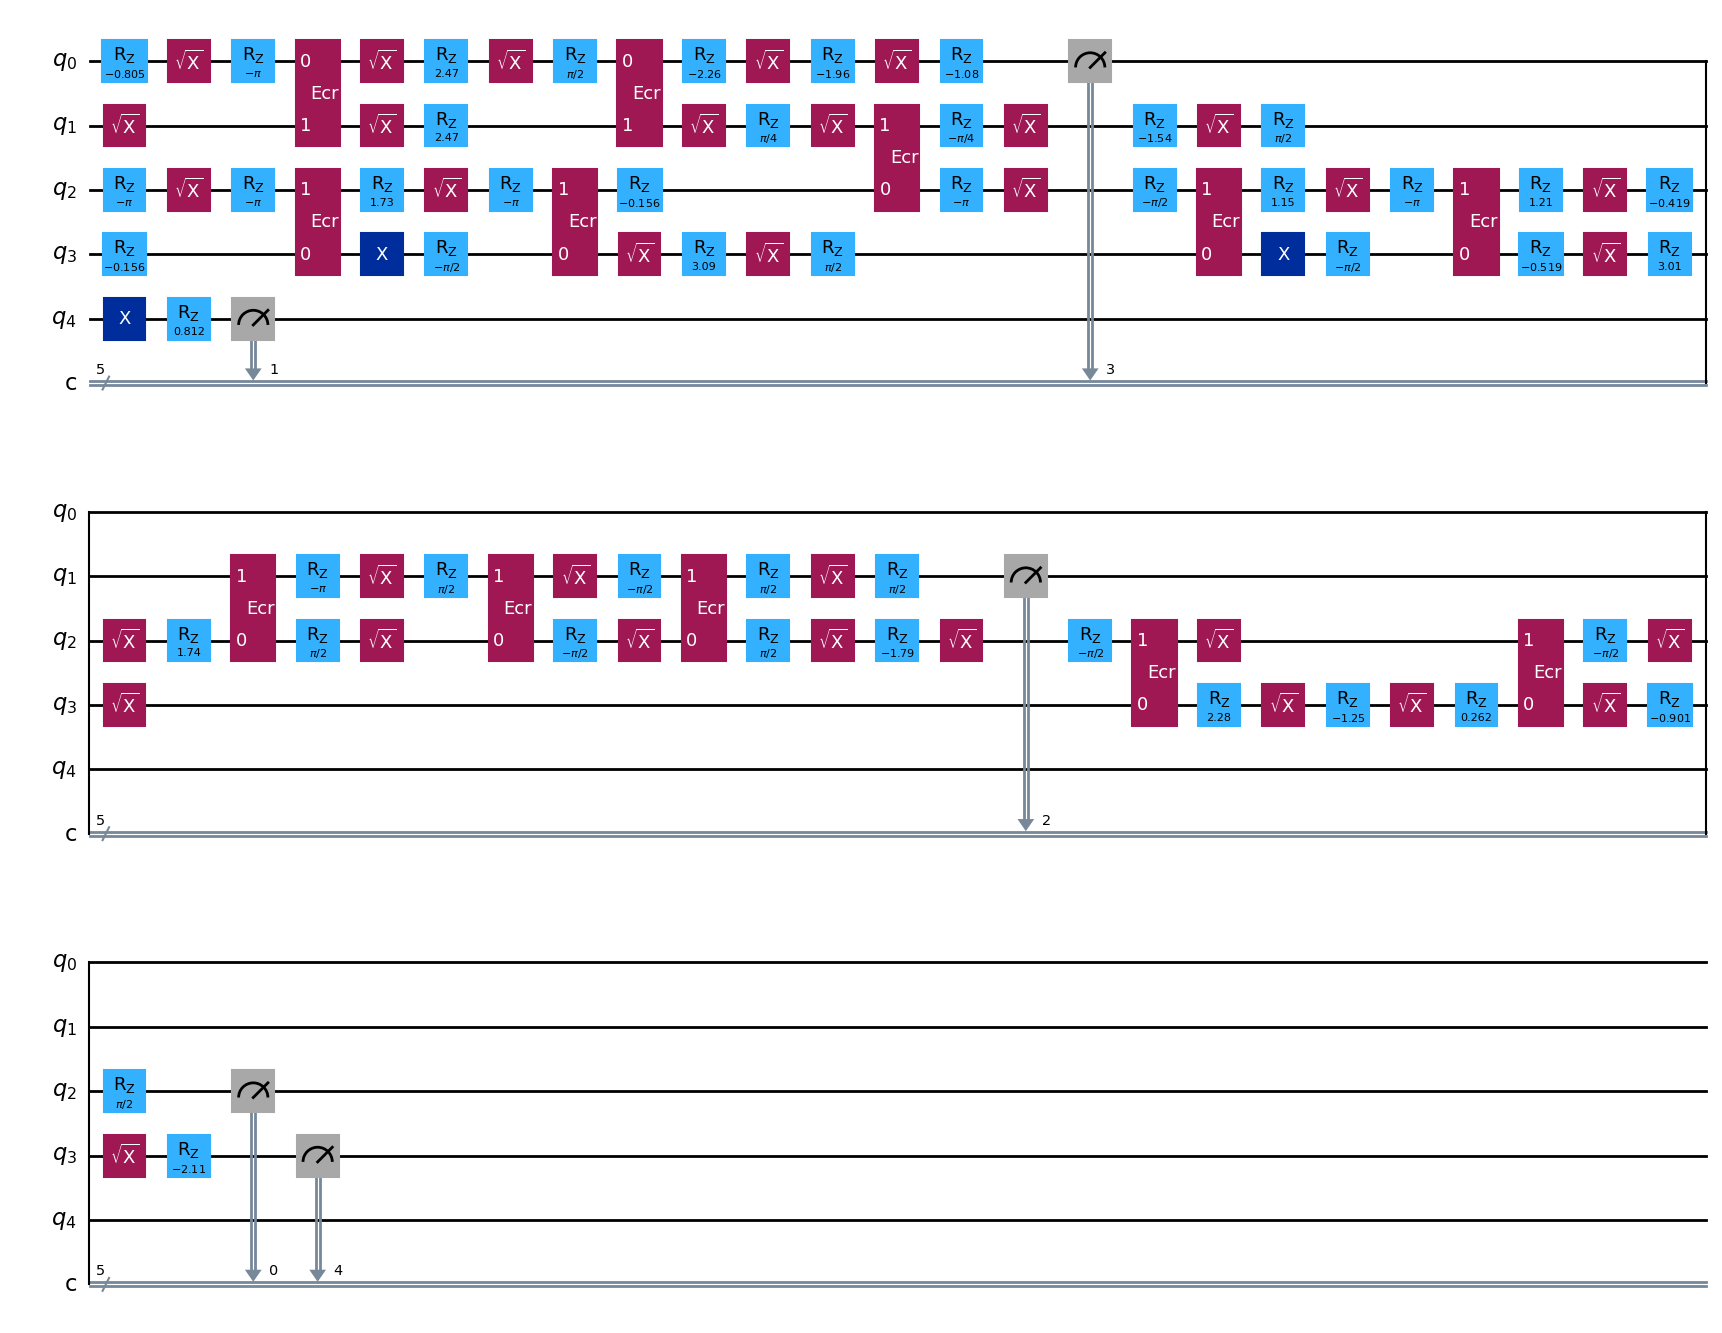

In [4]:
# Step 3: New circuit with only the virtual qubits
num_virtual_qubits = len(active_physical_qubits)
qr_virtual = QuantumRegister(num_virtual_qubits, 'q')
cr_virtual = ClassicalRegister(num_virtual_qubits, 'c')
reduced_circ = QuantumCircuit(qr_virtual, cr_virtual)

# Step 4: Copy instructions to new circuit with remapped qubits
for instr in transpiled_circ.data:
    new_qargs = [qr_virtual[hardware_to_virtual[q._index]] for q in instr.qubits]
    new_cargs = [cr_virtual[transpiled_circ.find_bit(c).index] for c in instr.clbits]
    reduced_circ.append(instr.operation, new_qargs, new_cargs)

reduced_circ.draw('mpl')

In [5]:
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp

# ------------------------- IDEAL SIMULATION -------------------------
ideal_qc = reduced_circ.remove_final_measurements(inplace=False)
n_qubits = reduced_circ.num_qubits

# Define ⟨Z⟩ for each qubit
for q in range(n_qubits):
    label = ['I'] * n_qubits
    label[q] = 'Z'
    op = SparsePauliOp.from_list([("", 1.0)] if n_qubits == 0 else [("".join(label), 1.0)])
    ideal_qc.save_expectation_value(op, qubits=list(range(n_qubits)), label=f"z{q}")

# Define joint Z operator ⟨Z⊗Z⊗...⊗Z⟩
joint_label = ['Z'] * n_qubits
joint_op = SparsePauliOp.from_list([("".join(joint_label), 1.0)])
ideal_qc.save_expectation_value(joint_op, qubits=list(range(n_qubits)), label="joint_z")

# Simulate with statevector
sim_ideal = AerSimulator(method="statevector")
res_ideal = sim_ideal.run(ideal_qc).result()

z_expect_ideal = [res_ideal.data(0)[f"z{q}"] for q in range(n_qubits)]
joint_z_expect_ideal = res_ideal.data(0)["joint_z"]

# Print Ideal Results
print("\n--- IDEAL (Aer Statevector) ---")
for q, val in enumerate(z_expect_ideal):
    print(f"⟨Z{q}⟩ = {val:.4f}")
print(f"⟨Z⊗Z⊗...⊗Z⟩ = {joint_z_expect_ideal:.4f}")

# ------------------------- NOISY SIMULATION -------------------------
noisy_qc = reduced_circ.copy()
noisy_qc.measure_all(inplace=True)

sim_noisy = AerSimulator(noise_model=noise_model, method="statevector")
res_noisy = sim_noisy.run(noisy_qc, shots=10_000).result()
counts = res_noisy.get_counts()

z_expect_noisy = []
for q in range(n_qubits):
    z = 0
    for bitstring, count in counts.items():
        bit = bitstring[::-1][q]
        z += count if bit == '0' else -count
    z_expect_noisy.append(z / 10_000)

joint_z_expect_noisy = 0
for bitstring, count in counts.items():
    parity = sum(int(bitstring[::-1][q]) for q in range(n_qubits)) % 2
    eigenvalue = (-1) ** parity
    joint_z_expect_noisy += count * eigenvalue
joint_z_expect_noisy /= 10_000

# Print Noisy Results
print("\n--- NOISY (Aer + IBM Noise Model) ---")
for q, val in enumerate(z_expect_noisy):
    print(f"⟨Z{q}⟩ ≈ {val:.4f}")
print(f"⟨Z⊗Z⊗...⊗Z⟩ ≈ {joint_z_expect_noisy:.4f}")


--- IDEAL (Aer Statevector) ---
⟨Z0⟩ = -1.0000
⟨Z1⟩ = 0.1203
⟨Z2⟩ = 0.0000
⟨Z3⟩ = 0.9075
⟨Z4⟩ = 0.1326
⟨Z⊗Z⊗...⊗Z⟩ = 0.0535

--- NOISY (Aer + IBM Noise Model) ---
⟨Z0⟩ ≈ 0.0086
⟨Z1⟩ ≈ -0.9648
⟨Z2⟩ ≈ 0.8020
⟨Z3⟩ ≈ 0.1228
⟨Z4⟩ ≈ 0.1102
⟨Z⊗Z⊗...⊗Z⟩ ≈ 0.0292


In [6]:
dag = circuit_to_dag(reduced_circ)

In [7]:
def extract_dag_data(dag):
    nodes, edges, edge_features, node_to_uid = {'gates': {}, 'input': {}, 'output': {}}, {}, {}, {}
    def idx(bit):
        return getattr(bit, 'index', getattr(bit, '_index', bit[1] if isinstance(bit, tuple) else None))
    for i, node in enumerate(dag.topological_nodes()):
        uid = f"node_{i}"
        node_to_uid[node] = uid
        qargs = [idx(q) for q in getattr(node, 'qargs', [])]
        cargs = [idx(c) for c in getattr(node, 'cargs', [])]
        if hasattr(node, 'op'):
            nodes['gates'][uid] = {'type': node.op.name, 'qargs': qargs, 'cargs': cargs}
        else:
            cat = 'input' if 'In' in type(node).__name__ else 'output'
            nodes[cat][uid] = {'type': type(node).__name__, 'qargs': qargs, 'cargs': cargs}
    for i, (src, dst, wire) in enumerate(dag.edges()):
        eid = f"edge_{i}"
        edges[eid] = (node_to_uid[src], node_to_uid[dst])
        edge_features[eid] = idx(wire)
    return nodes, edges, edge_features

nodes, edges, edge_features = extract_dag_data(dag)

In [8]:
def parse_calibration_csv(file_path, active_physical_qubits, hardware_to_virtual):
    df = pd.read_csv(file_path)
    cols_qubit = [
        'T1 (us)', 'T2 (us)', 'Frequency (GHz)', 'Anharmonicity (GHz)',
        'Readout assignment error ', 'Prob meas0 prep1 ',
        'Prob meas1 prep0 ', 'Readout length (ns)'
    ]
    qubit_info = {
        hardware_to_virtual[q]: {col: row[col] for col in cols_qubit}
        for _, row in df.iterrows() if (q := row["Qubit"]) in hardware_to_virtual
    }
    gate_errors = {g: {} for g in ["id", "rz", "sx", "x", "ecr"]}
    for _, row in df.iterrows():
        if (q := row["Qubit"]) not in hardware_to_virtual: continue
        vq = hardware_to_virtual[q]
        gate_errors["id"][vq] = row["ID error "]
        gate_errors["rz"][vq] = row["Z-axis rotation (rz) error "]
        gate_errors["sx"][vq] = row["\u221ax (sx) error "]
        gate_errors["x"][vq] = row["Pauli-X error "]
        for conn, val in re.findall(r'(\d+_\d+):([\d\.]+)', str(row["ECR error "])):
            if all((p := int(x)) in hardware_to_virtual for x in conn.split('_')):
                vp = tuple(sorted(hardware_to_virtual[int(x)] for x in conn.split('_')))
                gate_errors["ecr"].setdefault(vp, {})["error"] = float(val)
        for conn, val in re.findall(r'(\d+_\d+):([\d\.]+)', str(row["Gate time (ns)"])):
            if all((p := int(x)) in hardware_to_virtual for x in conn.split('_')):
                vp = tuple(sorted(hardware_to_virtual[int(x)] for x in conn.split('_')))
                gate_errors["ecr"].setdefault(vp, {})["Gate time"] = float(val)
    return qubit_info, gate_errors

calib_path = "ibm_brisbane_calibrations_2025-04-05T06_27_38Z.csv"
qubit_info, gate_errors = parse_calibration_csv(calib_path, active_physical_qubits, hardware_to_virtual)

In [9]:
def update_gate_nodes_with_errors(nodes, gate_errors):
    for nid, node in nodes["gates"].items():
        t, q = node["type"], node["qargs"]
        if t in {"rz", "sx", "x"} and q:
            node["error"] = gate_errors.get(t, {}).get(q[0], 0.0)
        elif t == "ecr" and len(q) == 2:
            node["error"] = gate_errors["ecr"].get(tuple(sorted(q)), {}).get("error", 0.0)
        else:
            node["error"] = 0.0
    return nodes

def update_edge_features_with_qubit_info(edge_features, qubit_info):
    return {
        eid: {"qubit_id": q, "qubit_info": qubit_info.get(q, {})}
        for eid, q in edge_features.items()
    }

nodes = update_gate_nodes_with_errors(nodes, gate_errors)
edge_features = update_edge_features_with_qubit_info(edge_features, qubit_info)

In [10]:
def build_gnn_data(nodes, edges, edge_features, gate_errors, qubit_info, backend):
    types = sorted(set(backend.configuration().basis_gates + ["measure", "DAGInNode", "DAGOutNode"]))
    all_nodes = {**nodes["gates"], **nodes["input"], **nodes["output"]}
    node_names = list(all_nodes)
    node_to_idx = {name: i for i, name in enumerate(node_names)}
    def one_hot(t, T): return [int(t == s) for s in T]
    def node_features(node):
        return one_hot(node["type"], types) + [len(node.get("qargs", [])), len(node.get("cargs", [])), node.get("error", 0.0), node.get("time", 0.0)]
    X = np.array([node_features(all_nodes[n]) for n in node_names])
    edge_index = np.array([[node_to_idx[s], node_to_idx[d]] for s, d in edges.values()]).T
    keys = [
        'T1 (us)', 'T2 (us)', 'Frequency (GHz)', 'Anharmonicity (GHz)',
        'Readout assignment error ', 'Prob meas0 prep1 ',
        'Prob meas1 prep0 ', 'Readout length (ns)'
    ]
    edge_attr = np.array([
        [feat["qubit_info"].get(k, 0.0) for k in keys] for feat in edge_features.values()
    ])
    return Data(
        x=torch.tensor(X, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        z_noisy=torch.tensor(z_expect_noisy, dtype=torch.float),
        z_ideal=torch.tensor(z_expect_ideal, dtype=torch.float)
    )

gnn_data = build_gnn_data(nodes, edges, edge_features, gate_errors, qubit_info, backend)

## 📊 GNN Data Feature Explanation

---

### 🔹 Node Features (`data.x`)
Each node represents either:
- A quantum gate (like `rz`, `sx`, `x`, `ecr`, or `measure`)
- A special DAG input/output node (`DAGInNode`, `DAGOutNode`)

**Each node's feature vector includes:**

1. **One-hot encoding of gate type**
   - Encoded over: `basis_gates + ["measure", "DAGInNode", "DAGOutNode"]`
   - Example: If `basis_gates = ["rz", "sx", "x", "ecr"]`, then one-hot vector length is 7.
   - For example: `rz` → `[1, 0, 0, 0, 0, 0, 0]`

2. **Number of qubits used** – `1` for single-qubit gates, `2` for two-qubit gates, etc.

3. **Number of classical bits used** – Useful for measurement gates

4. **Gate error rate** – Taken from the calibration data (based on virtual-to-physical mapping)

5. **Gate execution time** – Currently set to `0.0` as a placeholder (non-zero for ECR Gates)

---

### 🔹 Edge Index (`data.edge_index`)
- Represents a directed edge between nodes in the DAG
- Shape is `[2, num_edges]`
- Encodes gate execution order and qubit flow

---

### 🔹 Edge Attributes (`data.edge_attr`)
Each edge corresponds to a virtual qubit wire and carries calibration info for that qubit.

Each edge has these 8 features:
1. T1 time (in microseconds)
2. T2 time (in microseconds)
3. Frequency (GHz)
4. Anharmonicity (GHz)
5. Readout assignment error
6. Probability of measuring 0 when prepared in 1
7. Probability of measuring 1 when prepared in 0
8. Readout length (in nanoseconds)

All values are extracted from IBM’s calibration CSV using the virtual-to-physical qubit mapping from the transpiled circuit.

---

### 🔹 Additional Data: `z_ideal`, `z_noisy`, `z_joint_ideal`, `z_joint_noisy`

These capture the Pauli-Z expectation values from ideal and noisy simulations.

**z_ideal** – List of expected Z values on each qubit from ideal (noiseless) simulation  
**z_noisy** – List of expected Z values on each qubit from noisy simulation  
**z_joint_ideal** – Expected value of the tensor product Z ⊗ Z ⊗ ... ⊗ Z from ideal state  
**z_joint_noisy** – Same as above, from noisy output  

---

### 🔸 How These Values Were Computed:

1. **Circuit Transpilation**
   - Random circuits are transpiled to a real IBM backend (e.g., `ibm_brisbane`)
   - The transpilation adapts to hardware constraints and topology

2. **Qubit Mapping**
   - Physical qubits used in the transpiled circuit are extracted
   - These are remapped to a smaller range of virtual qubits (like [0, 1, 2])

3. **Ideal Simulation**
   - Uses `AerSimulator` in `statevector` mode
   - Measures Pauli-Z expectations using `SparsePauliOp`

4. **Noisy Simulation**
   - Uses the same simulator but with a noise model from the IBM backend
   - Runs many shots (e.g., 10,000)
   - Estimates Z expectation per qubit and full parity from the results

5. **All values are stored in the final PyG `Data` object**
